# Purpose
This notebook will aim to simulate 2 2x2 surface codes via lattice surgery to demonstrate the $M$ value of $X_LX_L$ or $Z_LZ_L$. Unlike STIM which is a stabilizer circuit simulator, Qiskit is a full statevector simulator that can simulate actual qubit behavior. However as a result, it scales very poorly, being $2^n$.

$2^n$ represents the total amplitudes being represented. Given that each amplitude is stored in a statevector ~ 16 bytes, representing $n$ qubits require $2^n * 16$ bytes.

Therefore for a two 2x2 surface codes undergoing merging, it requires $2^{20}*16 \approx 16MB$

In [ ]:
import sys
import os

# Add the target directory to the search path
sys.path.append(os.path.abspath('/home/samir/research/experiments/surface_code_simulations'))


In [3]:
from lib.surface_code.surface_code import SurfaceCodeCircuit, RoughMergeCircuit, SmoothMergeCircuit
from lib.surface_code.utils import measure_parity

from qiskit_aer import AerSimulator

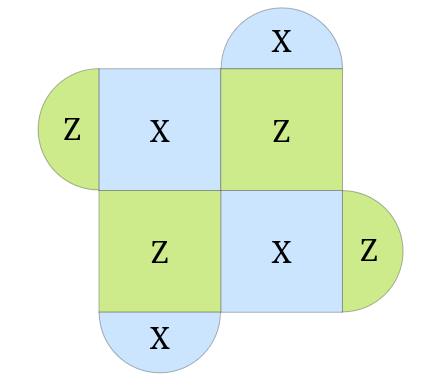

In [4]:
surface_code = SurfaceCodeCircuit(d=2, T=5, basis="z")



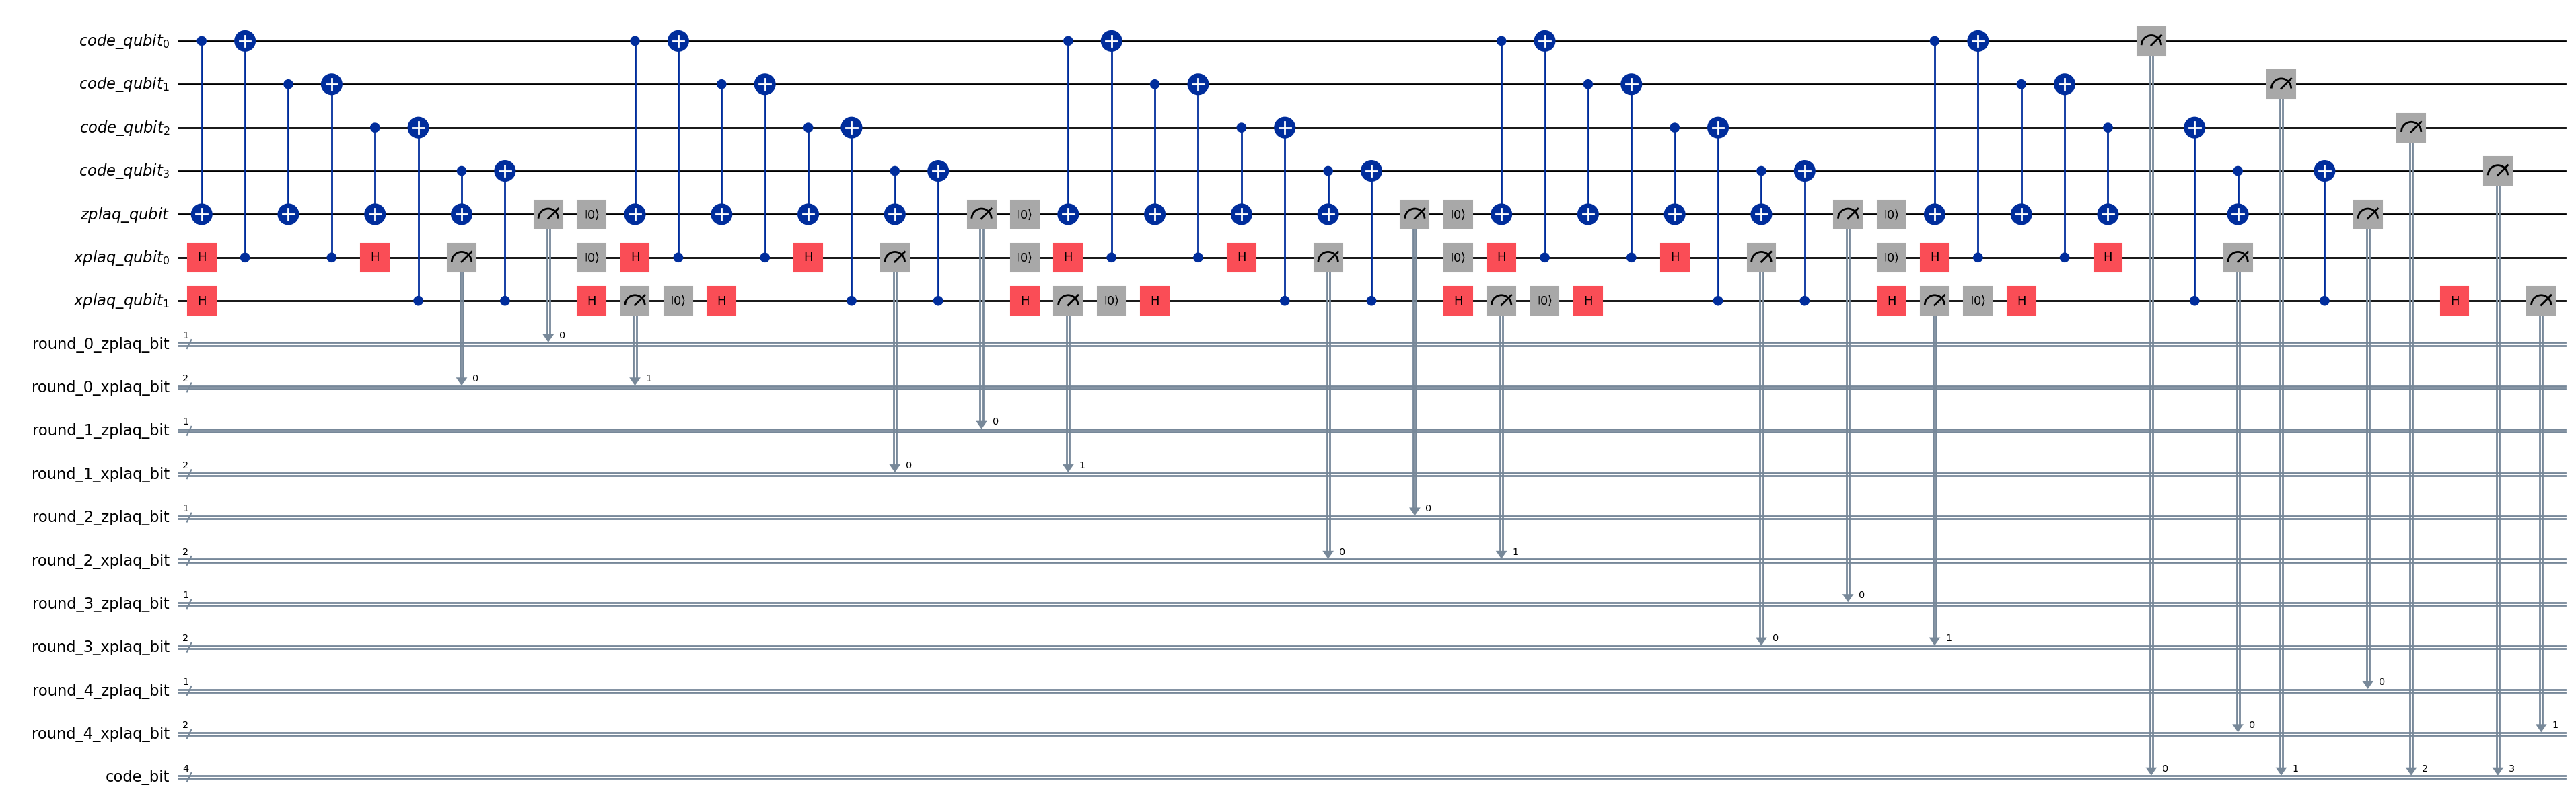

In [5]:
surface_code.circuit["0"].draw(output='mpl', fold=-1)

In [6]:
surface_code.code_bit

ClassicalRegister(4, 'code_bit')

In [7]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
# error = depolarizing_error(0.5, 2)
# noise_model.add_all_qubit_quantum_error(error, ["cx"])

In [8]:
sim = AerSimulator(method="statevector", noise_model=noise_model)
result = sim.run(surface_code.circuit["0"], shots=10).result()


# .get_counts() displays the results of classical registers. little endian so the last register is first.
count = result.get_counts()

print(count)
# for m in mem:
#     print(surface_code.string2raw_logicals(m))

{'0011 01 0 01 0 01 0 01 0 01 0': 2, '1111 11 0 11 0 11 0 11 0 11 0': 1, '1111 10 0 10 0 10 0 10 0 10 0': 1, '0000 11 0 11 0 11 0 11 0 11 0': 3, '1100 10 0 10 0 10 0 10 0 10 0': 1, '0011 11 0 11 0 11 0 11 0 11 0': 2}


In [9]:
# for key, val in count.items():
#     print(measure_parity(key))

In [10]:
for key, val in count.items():

    nodes = surface_code.string2nodes(key)
    raw_logicals = surface_code.string2raw_logicals(key)
    # print(nodes)
    print(nodes)
    # print(surface_code.check_nodes(nodes))


[]
[]
[]
[]
[]
[]


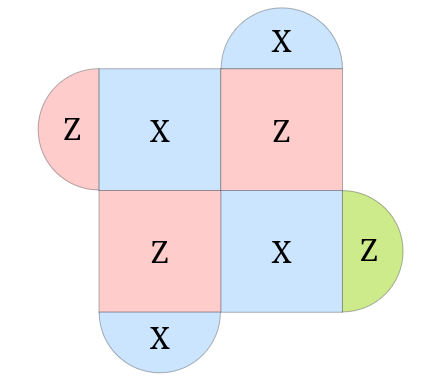

In [11]:
nodes

[]

In [12]:
from lib.surface_code.decoder import MWPM_Decoder

decoder = MWPM_Decoder(surface_code)

decoder.decode(nodes, raw_logicals)

ValueError: Edge (0, 18446744073709551615) already exists in the graph. Parallel edges not permitted with the provided `disallow` `merge_strategy`. Please provide a different `merge_strategy`.

In [13]:
for key, val in count.items():

    nodes = surface_code.string2raw_logicals(key)
    print(nodes)
    # print(surface_code.check_nodes(nodes))

['0', '0']
['0', '0']
['0', '0']
['0', '0']
['0', '0']
['0', '0']


## Imports

In [2]:
import sys
import os

# Add the target directory to the search path
sys.path.append(os.path.abspath('/home/samir/research/experiments/surface_code_simulations'))
from lib.surface_code.surface_code import SurfaceCodeCircuit, RoughMergeCircuit, SmoothMergeCircuit
from lib.surface_code.utils import measure_parity

from qiskit_aer import AerSimulator

## Smooth Merge in Z basis. Both Qubits |0>

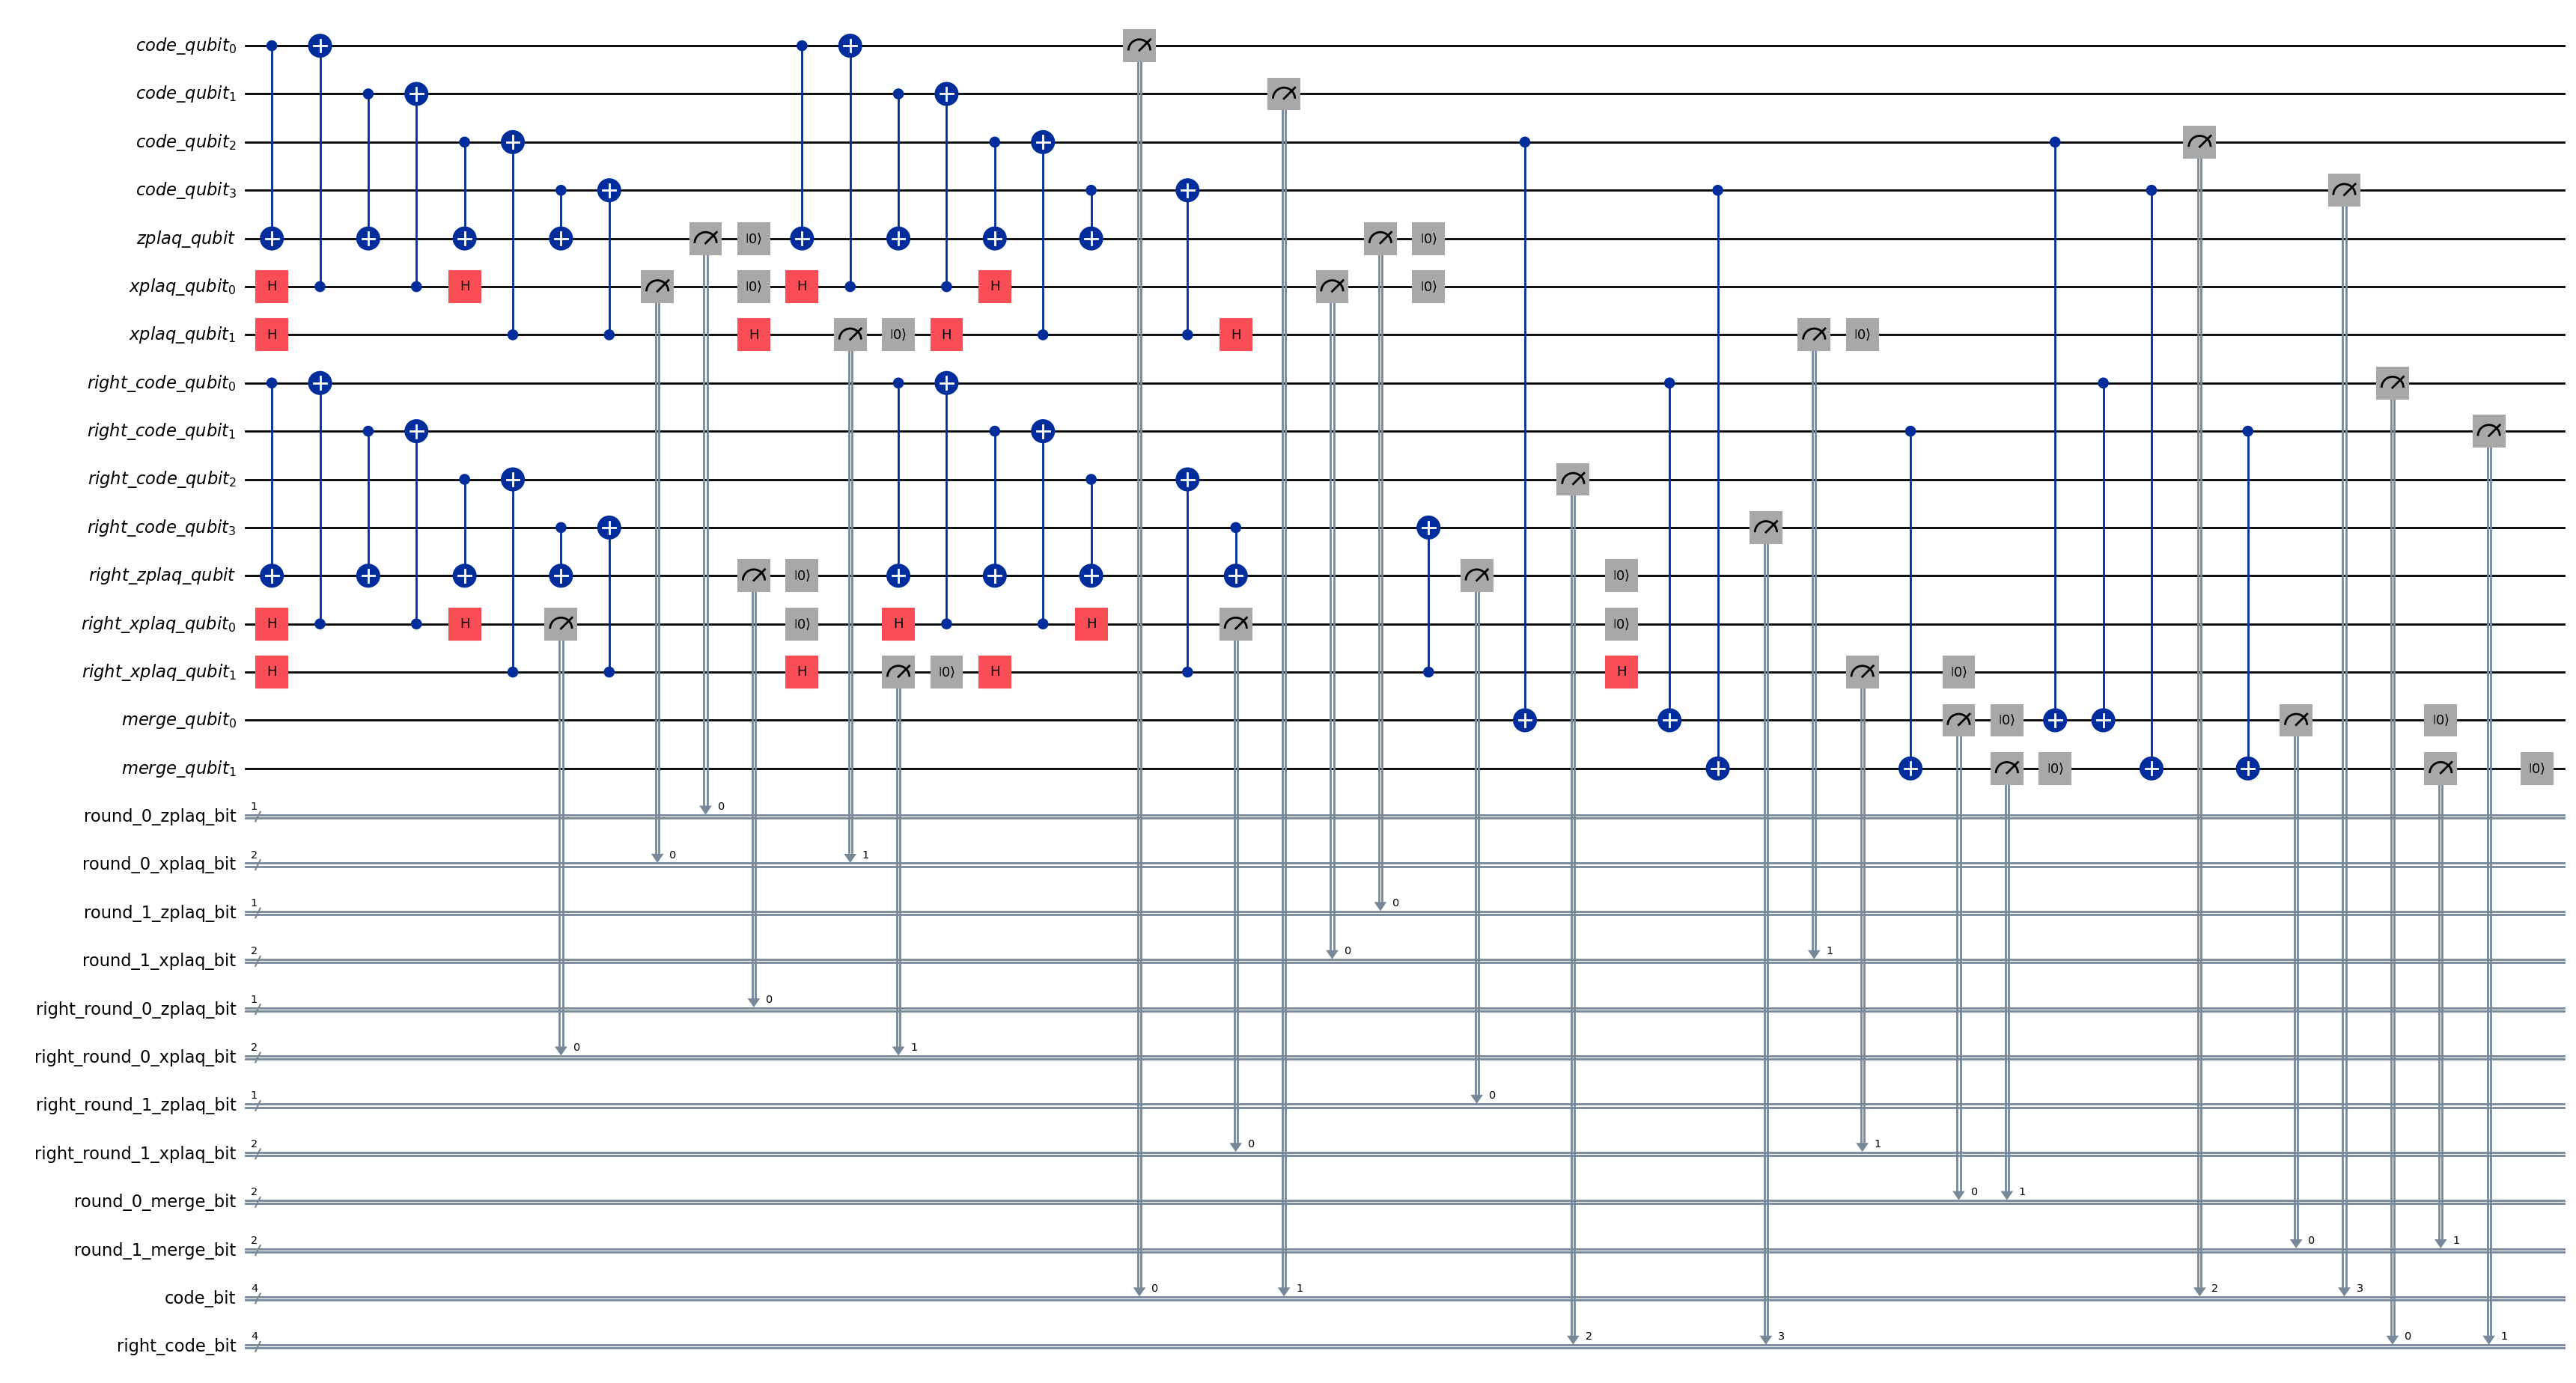

In [4]:
s_merge_circuit_zb = SmoothMergeCircuit(d=2, T=3, basis="z", flip=None)
s_merge_circuit_zb.circuit["0"].draw(output='mpl', fold=-1)

In [5]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
# error = depolarizing_error(0.5, 2)
# noise_model.add_all_qubit_quantum_error(error, ["cx"])

In [6]:
sim = AerSimulator(method="statevector")
result = sim.run(s_merge_circuit_zb.circuit["0"], shots=100).result()


# .get_counts() displays the results of classical registers. little endian so the last register is first.
count = result.get_counts()

print(count)
# for m in mem:
#     print(surface_code.string2raw_logicals(m))

{'1100 0011 00 00 11 0 11 0 10 0 10 0': 1, '0011 0000 11 11 11 0 11 0 00 0 00 0': 1, '1100 1100 11 11 00 0 00 0 11 0 11 0': 1, '1100 1111 11 11 11 0 11 0 10 0 10 0': 1, '0011 1100 00 00 00 0 00 0 01 0 01 0': 1, '0000 1111 11 11 10 0 10 0 10 0 10 0': 1, '1100 0000 00 00 00 0 00 0 01 0 01 0': 1, '1111 0000 11 11 11 0 11 0 10 0 10 0': 1, '0011 0011 11 11 10 0 10 0 10 0 10 0': 1, '0000 0000 00 00 01 0 01 0 01 0 01 0': 1, '0011 1111 00 00 10 0 10 0 00 0 00 0': 1, '0000 1100 11 11 11 0 11 0 00 0 00 0': 2, '0011 1100 00 00 01 0 01 0 01 0 01 0': 2, '1111 0011 11 11 11 0 11 0 11 0 11 0': 1, '0011 1111 00 00 11 0 11 0 11 0 11 0': 1, '1111 0011 11 11 00 0 00 0 00 0 00 0': 1, '1100 1100 11 11 01 0 01 0 01 0 01 0': 1, '0011 1111 00 00 00 0 00 0 01 0 01 0': 1, '1100 0011 00 00 10 0 10 0 01 0 01 0': 3, '1111 0011 11 11 00 0 00 0 10 0 10 0': 1, '1100 0011 00 00 01 0 01 0 10 0 10 0': 1, '1100 0011 00 00 11 0 11 0 00 0 00 0': 1, '1111 0000 11 11 11 0 11 0 00 0 00 0': 1, '1100 0011 00 00 01 0 01 0 11 0 1

In [7]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 0
even parity 100


## Smooth Merge in Z Basis. Left Qubit |1> Right Qubit |0>

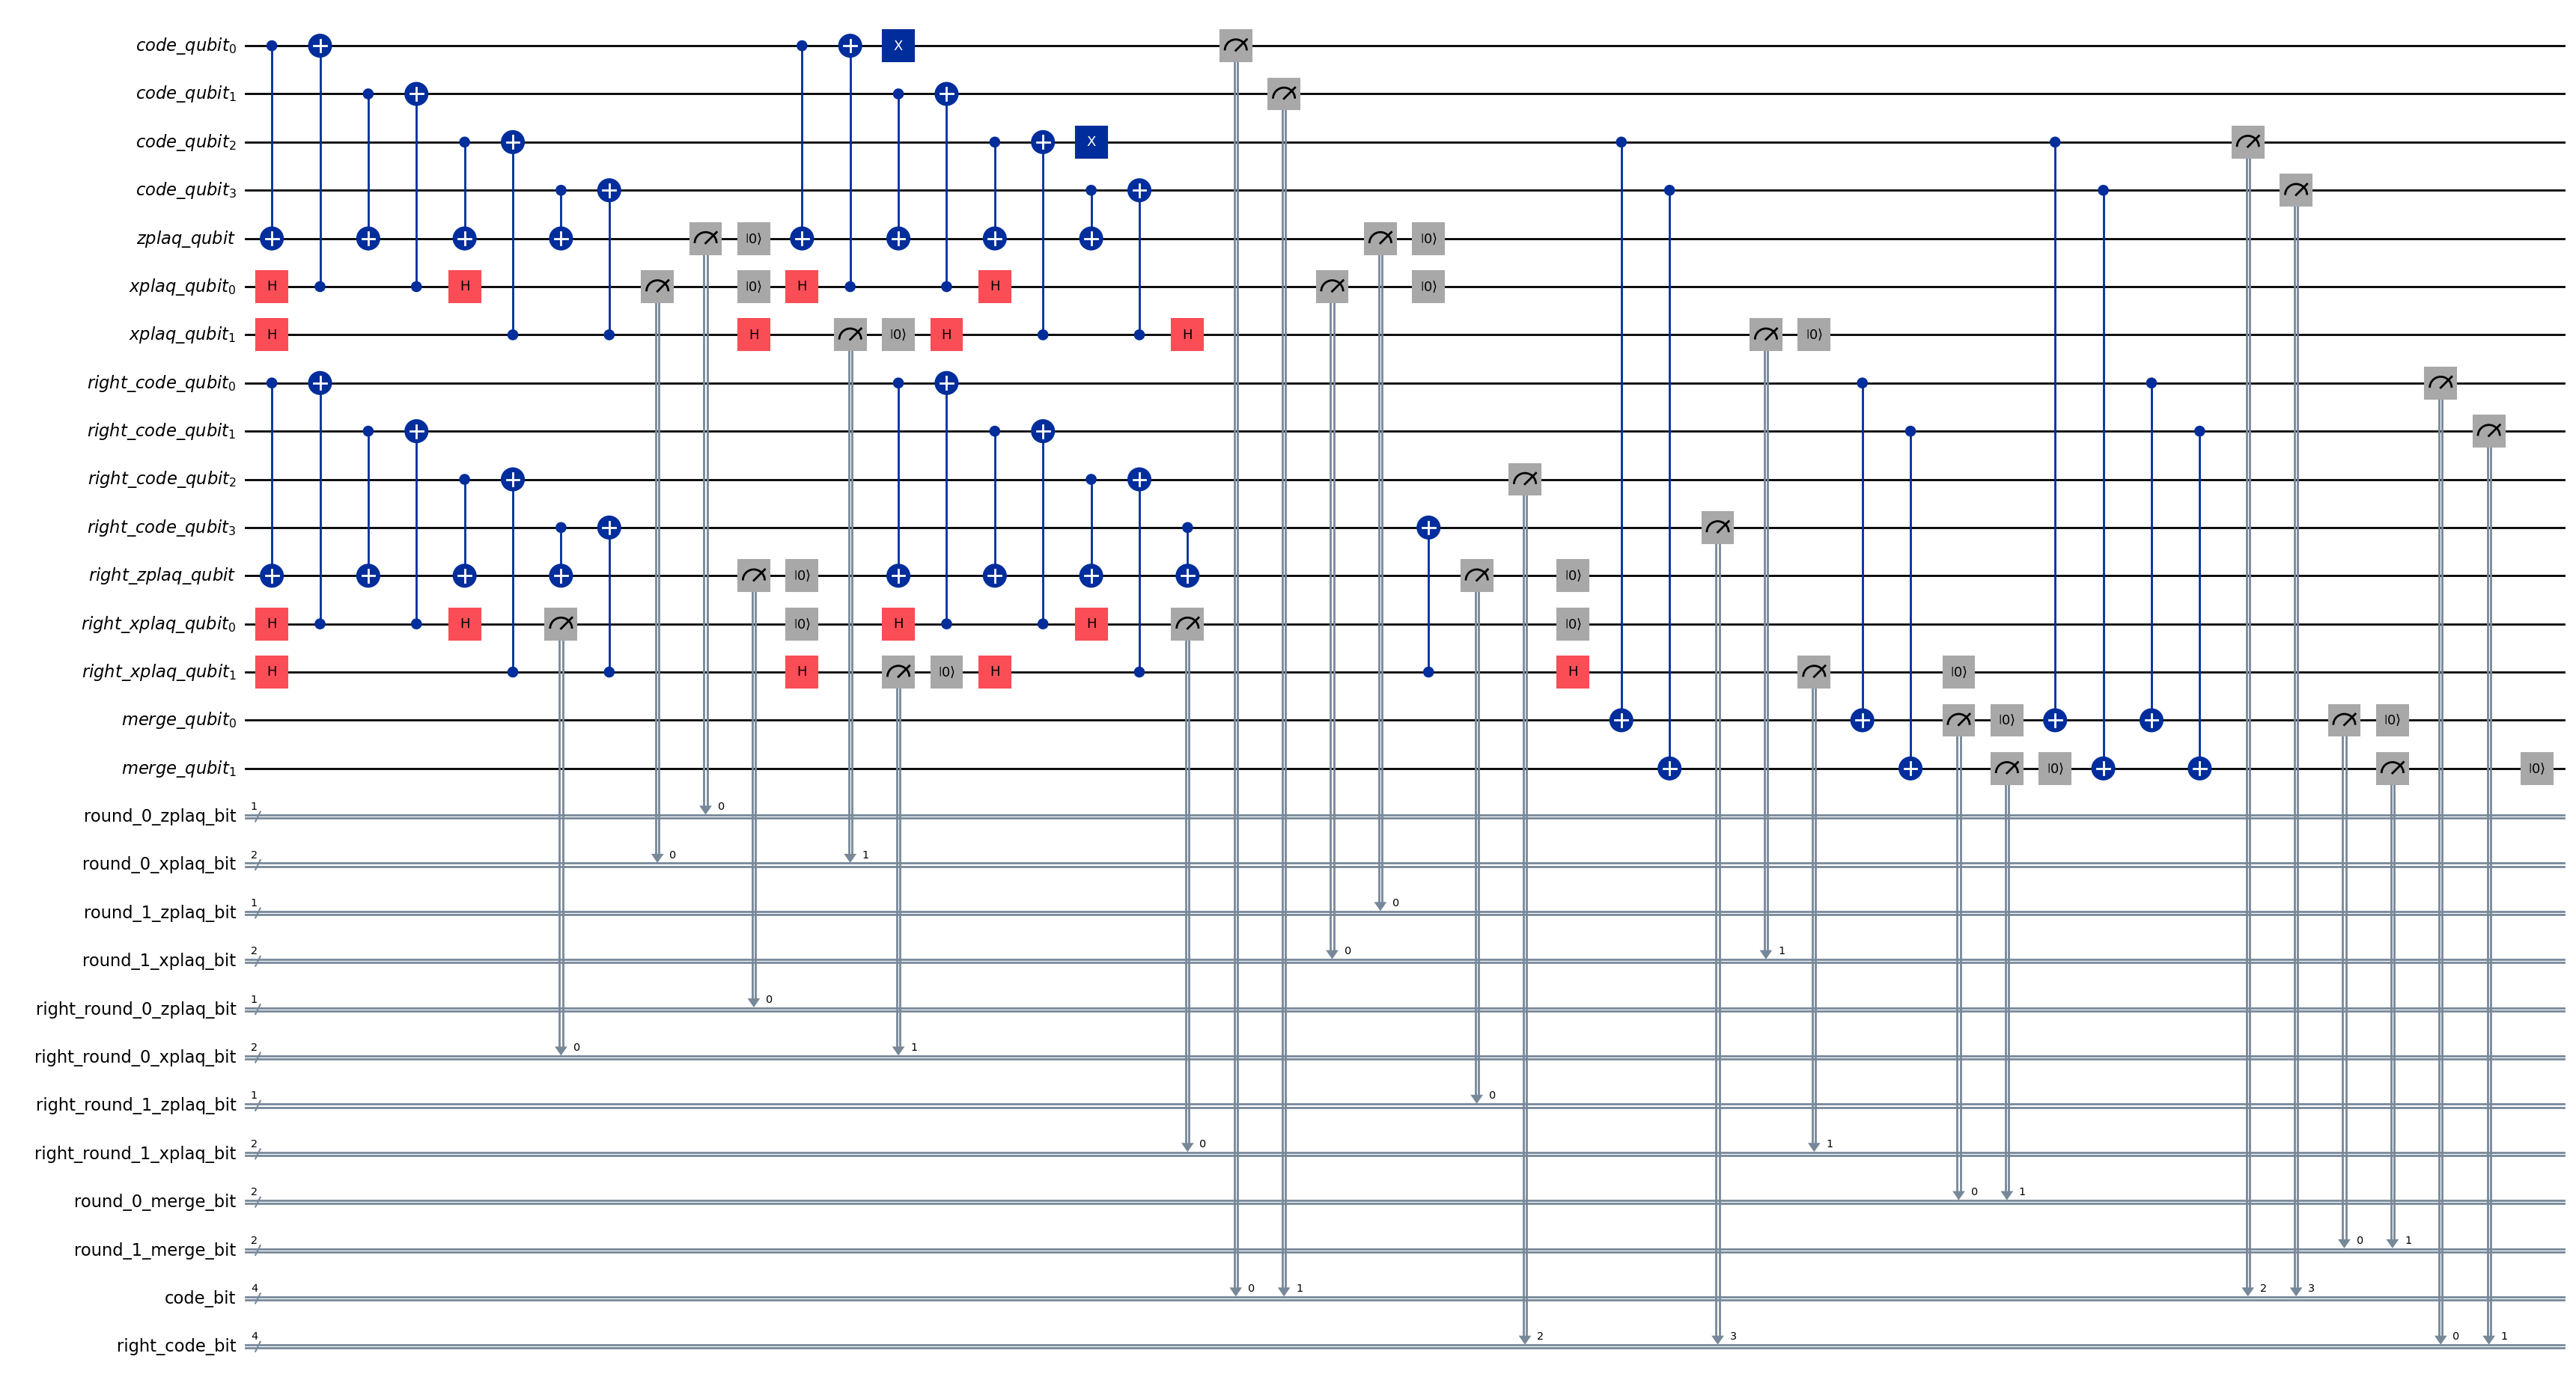

In [8]:
s_merge_circuit_zb_xf = SmoothMergeCircuit(d=2, T=3, basis="z", flip="x")
s_merge_circuit_zb_xf.circuit["0"].draw(output='mpl', fold=-1)

In [9]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
sim = AerSimulator(method="statevector")
result = sim.run(s_merge_circuit_zb_xf.circuit["0"], shots=100).result()

count = result.get_counts()

print(count)


{'1111 1001 01 01 10 0 10 0 01 0 01 0': 1, '1100 0101 01 01 11 0 11 0 01 0 01 0': 1, '1111 0101 10 10 00 0 00 0 01 0 01 0': 1, '1111 0101 10 10 10 0 10 0 10 0 10 0': 1, '0000 0101 01 01 11 0 11 0 00 0 00 0': 1, '1111 0110 10 10 10 0 10 0 10 0 10 0': 1, '0011 1001 01 01 00 0 00 0 00 0 00 0': 1, '1100 0110 01 01 11 0 11 0 10 0 10 0': 1, '0011 1001 01 01 11 0 11 0 01 0 01 0': 1, '0000 0110 01 01 01 0 01 0 01 0 01 0': 1, '1100 1001 10 10 11 0 11 0 10 0 10 0': 1, '0000 0110 01 01 00 0 00 0 10 0 10 0': 1, '1100 0110 01 01 00 0 00 0 11 0 11 0': 1, '1111 1010 01 01 01 0 01 0 10 0 10 0': 2, '1111 1001 01 01 01 0 01 0 00 0 00 0': 1, '1111 1010 01 01 11 0 11 0 00 0 00 0': 1, '0011 1010 01 01 00 0 00 0 10 0 10 0': 1, '1111 0110 10 10 10 0 10 0 11 0 11 0': 1, '0011 1010 01 01 10 0 10 0 00 0 00 0': 1, '0011 0110 10 10 00 0 00 0 10 0 10 0': 1, '1111 0101 10 10 00 0 00 0 10 0 10 0': 1, '0011 1001 01 01 10 0 10 0 10 0 10 0': 1, '1111 0101 10 10 10 0 10 0 00 0 00 0': 1, '0000 1010 10 10 01 0 01 0 11 0 1

In [10]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 100
even parity 0


## Smooth Merge in X basis. Both Qubits |+>

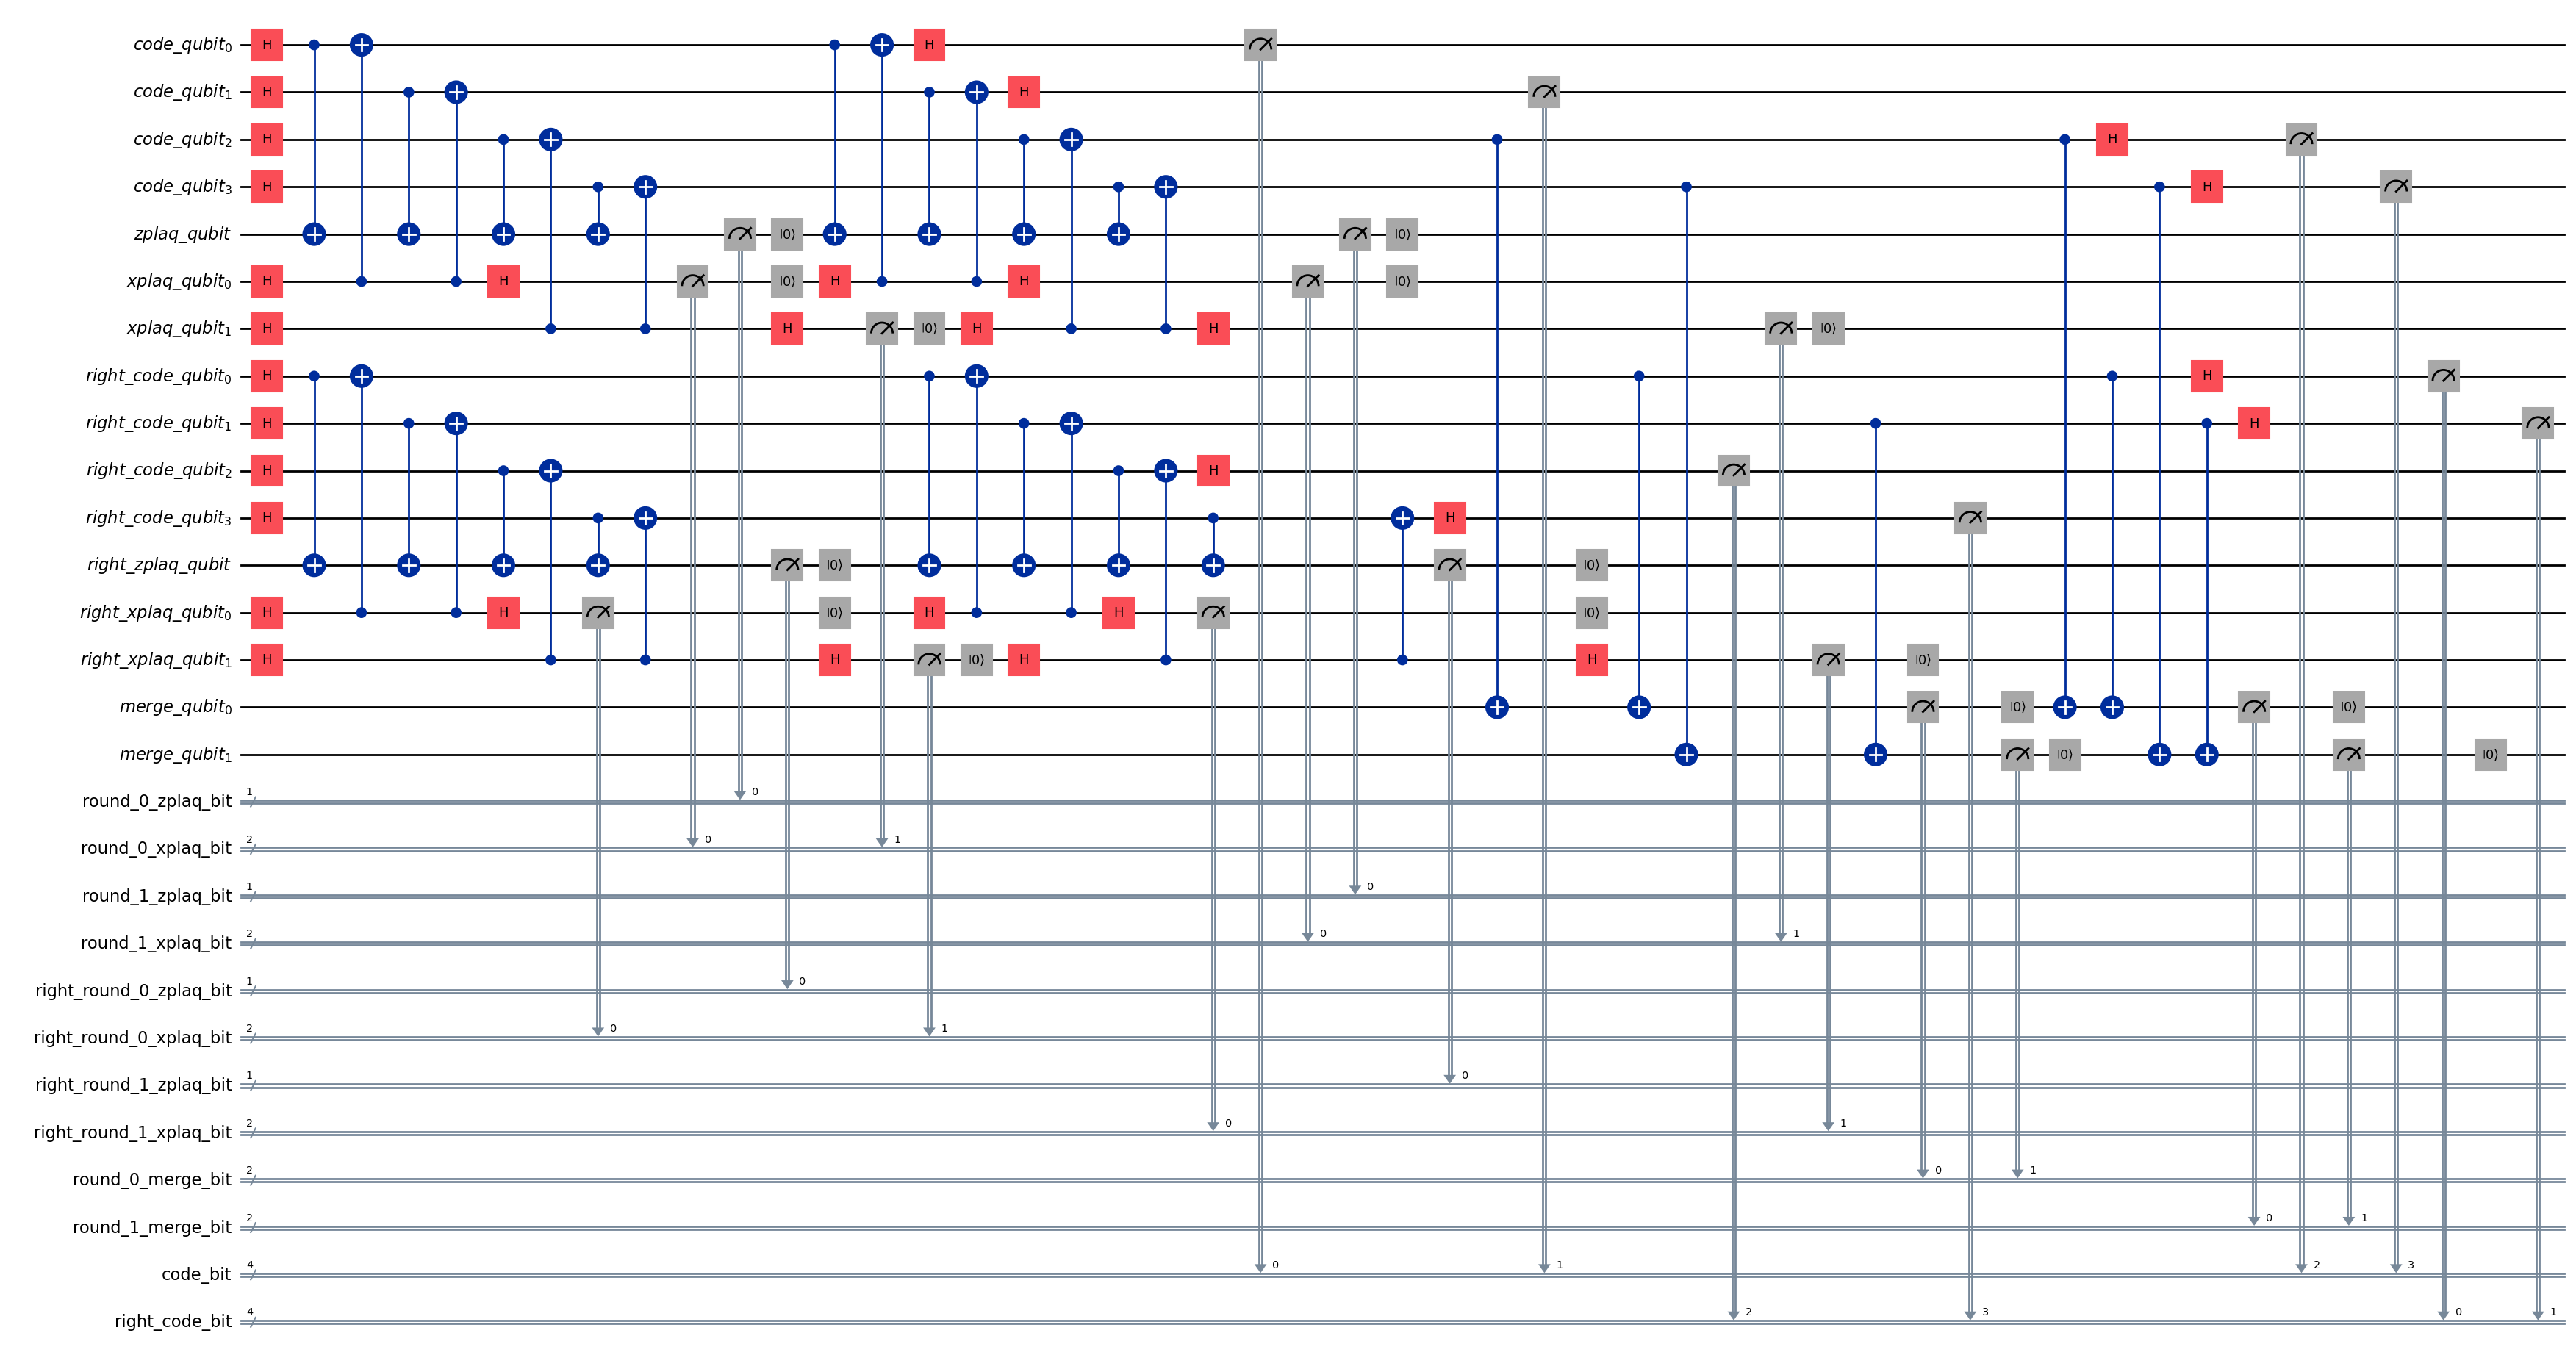

In [11]:
s_merge_circuit_xb = SmoothMergeCircuit(d=2, T=3, basis="x")
s_merge_circuit_xb.circuit["0"].draw(output='mpl', fold=-1)

In [12]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
sim = AerSimulator(method="statevector")
result = sim.run(s_merge_circuit_xb.circuit["0"], shots=100).result()

count = result.get_counts()

print(count)


{'0000 0000 10 10 00 0 00 0 00 1 00 1': 1, '0001 1011 00 00 00 1 00 1 00 1 00 1': 1, '0000 0000 00 00 00 1 00 1 00 1 00 1': 1, '1100 1100 00 00 00 1 00 1 00 1 00 1': 1, '1100 0011 10 10 00 0 00 0 00 0 00 0': 1, '0001 1011 10 10 00 1 00 1 00 1 00 1': 1, '0001 1011 11 11 00 0 00 0 00 1 00 1': 1, '1111 0000 10 10 00 1 00 1 00 0 00 0': 1, '1100 1100 00 00 00 0 00 0 00 0 00 0': 1, '0000 1111 11 11 00 1 00 1 00 1 00 1': 1, '0001 0100 11 11 00 0 00 0 00 0 00 0': 1, '1110 0100 10 10 00 0 00 0 00 1 00 1': 1, '1100 0011 10 10 00 1 00 1 00 1 00 1': 2, '1110 0100 00 00 00 1 00 1 00 1 00 1': 1, '0001 1011 01 01 00 1 00 1 00 1 00 1': 1, '1100 0011 01 01 00 0 00 0 00 0 00 0': 1, '0000 0000 01 01 00 0 00 0 00 1 00 1': 1, '0000 0000 11 11 00 0 00 0 00 0 00 0': 1, '1100 0011 01 01 00 1 00 1 00 0 00 0': 1, '0010 0111 10 10 00 0 00 0 00 1 00 1': 2, '1111 0000 10 10 00 0 00 0 00 0 00 0': 1, '1100 0011 10 10 00 0 00 0 00 1 00 1': 1, '1101 0111 01 01 00 0 00 0 00 1 00 1': 1, '1101 1000 01 01 00 0 00 0 00 0 0

In [13]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 57
even parity 43


## Rough Merge in X basis. Both Qubits |+>

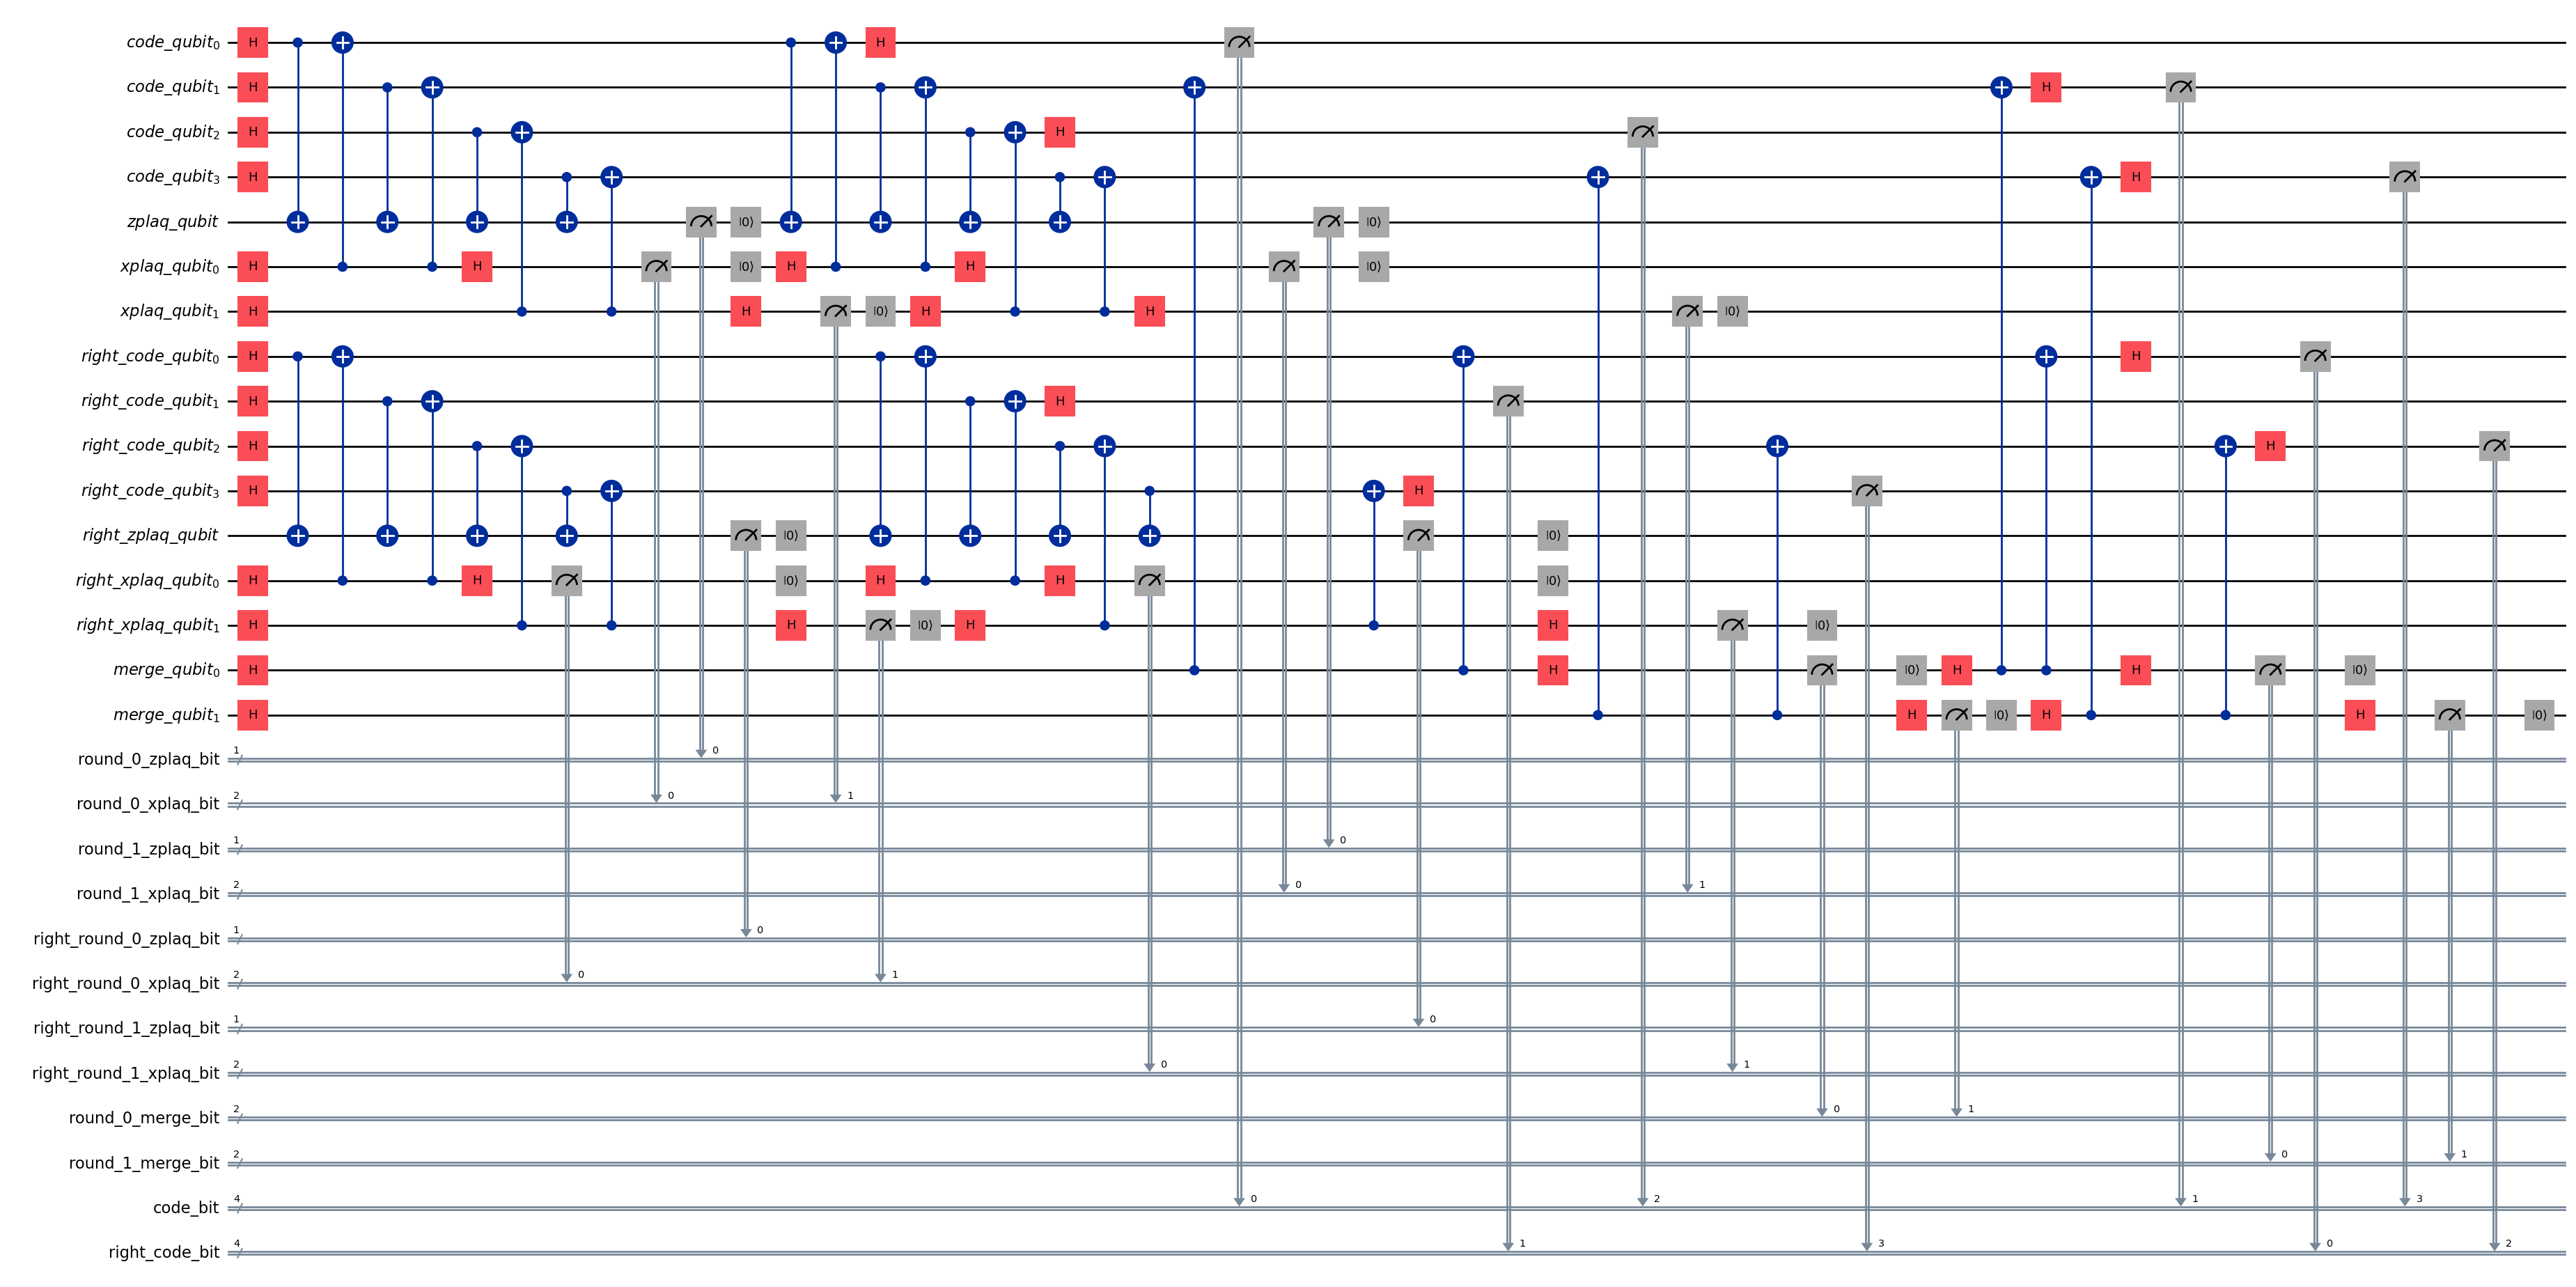

In [14]:
r_merge_circuit_xb = RoughMergeCircuit(d=2, T=3, basis="x")
r_merge_circuit_xb.circuit["0"].draw(output='mpl', fold=-1)

In [15]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
sim = AerSimulator(method="statevector")
result = sim.run(r_merge_circuit_xb.circuit["0"], shots=100).result()

count = result.get_counts()

print(count)


{'0000 1111 11 11 00 0 00 0 00 0 00 0': 3, '1111 1111 00 00 00 1 00 1 00 0 00 0': 6, '0000 0000 00 00 00 1 00 1 00 0 00 0': 7, '0000 0000 00 00 00 1 00 1 00 1 00 1': 7, '0000 1111 11 11 00 1 00 1 00 1 00 1': 10, '0000 1111 11 11 00 1 00 1 00 0 00 0': 10, '1111 0000 11 11 00 0 00 0 00 0 00 0': 9, '0000 0000 00 00 00 0 00 0 00 1 00 1': 7, '0000 1111 11 11 00 0 00 0 00 1 00 1': 10, '1111 1111 00 00 00 1 00 1 00 1 00 1': 4, '1111 1111 00 00 00 0 00 0 00 0 00 0': 3, '0000 0000 00 00 00 0 00 0 00 0 00 0': 4, '1111 1111 00 00 00 0 00 0 00 1 00 1': 6, '1111 0000 11 11 00 1 00 1 00 1 00 1': 7, '1111 0000 11 11 00 0 00 0 00 1 00 1': 4, '1111 0000 11 11 00 1 00 1 00 0 00 0': 3}


In [16]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 0
even parity 100


## Rough Merge in X Basis. Upper Qubit |-> Lower Qubit |+>

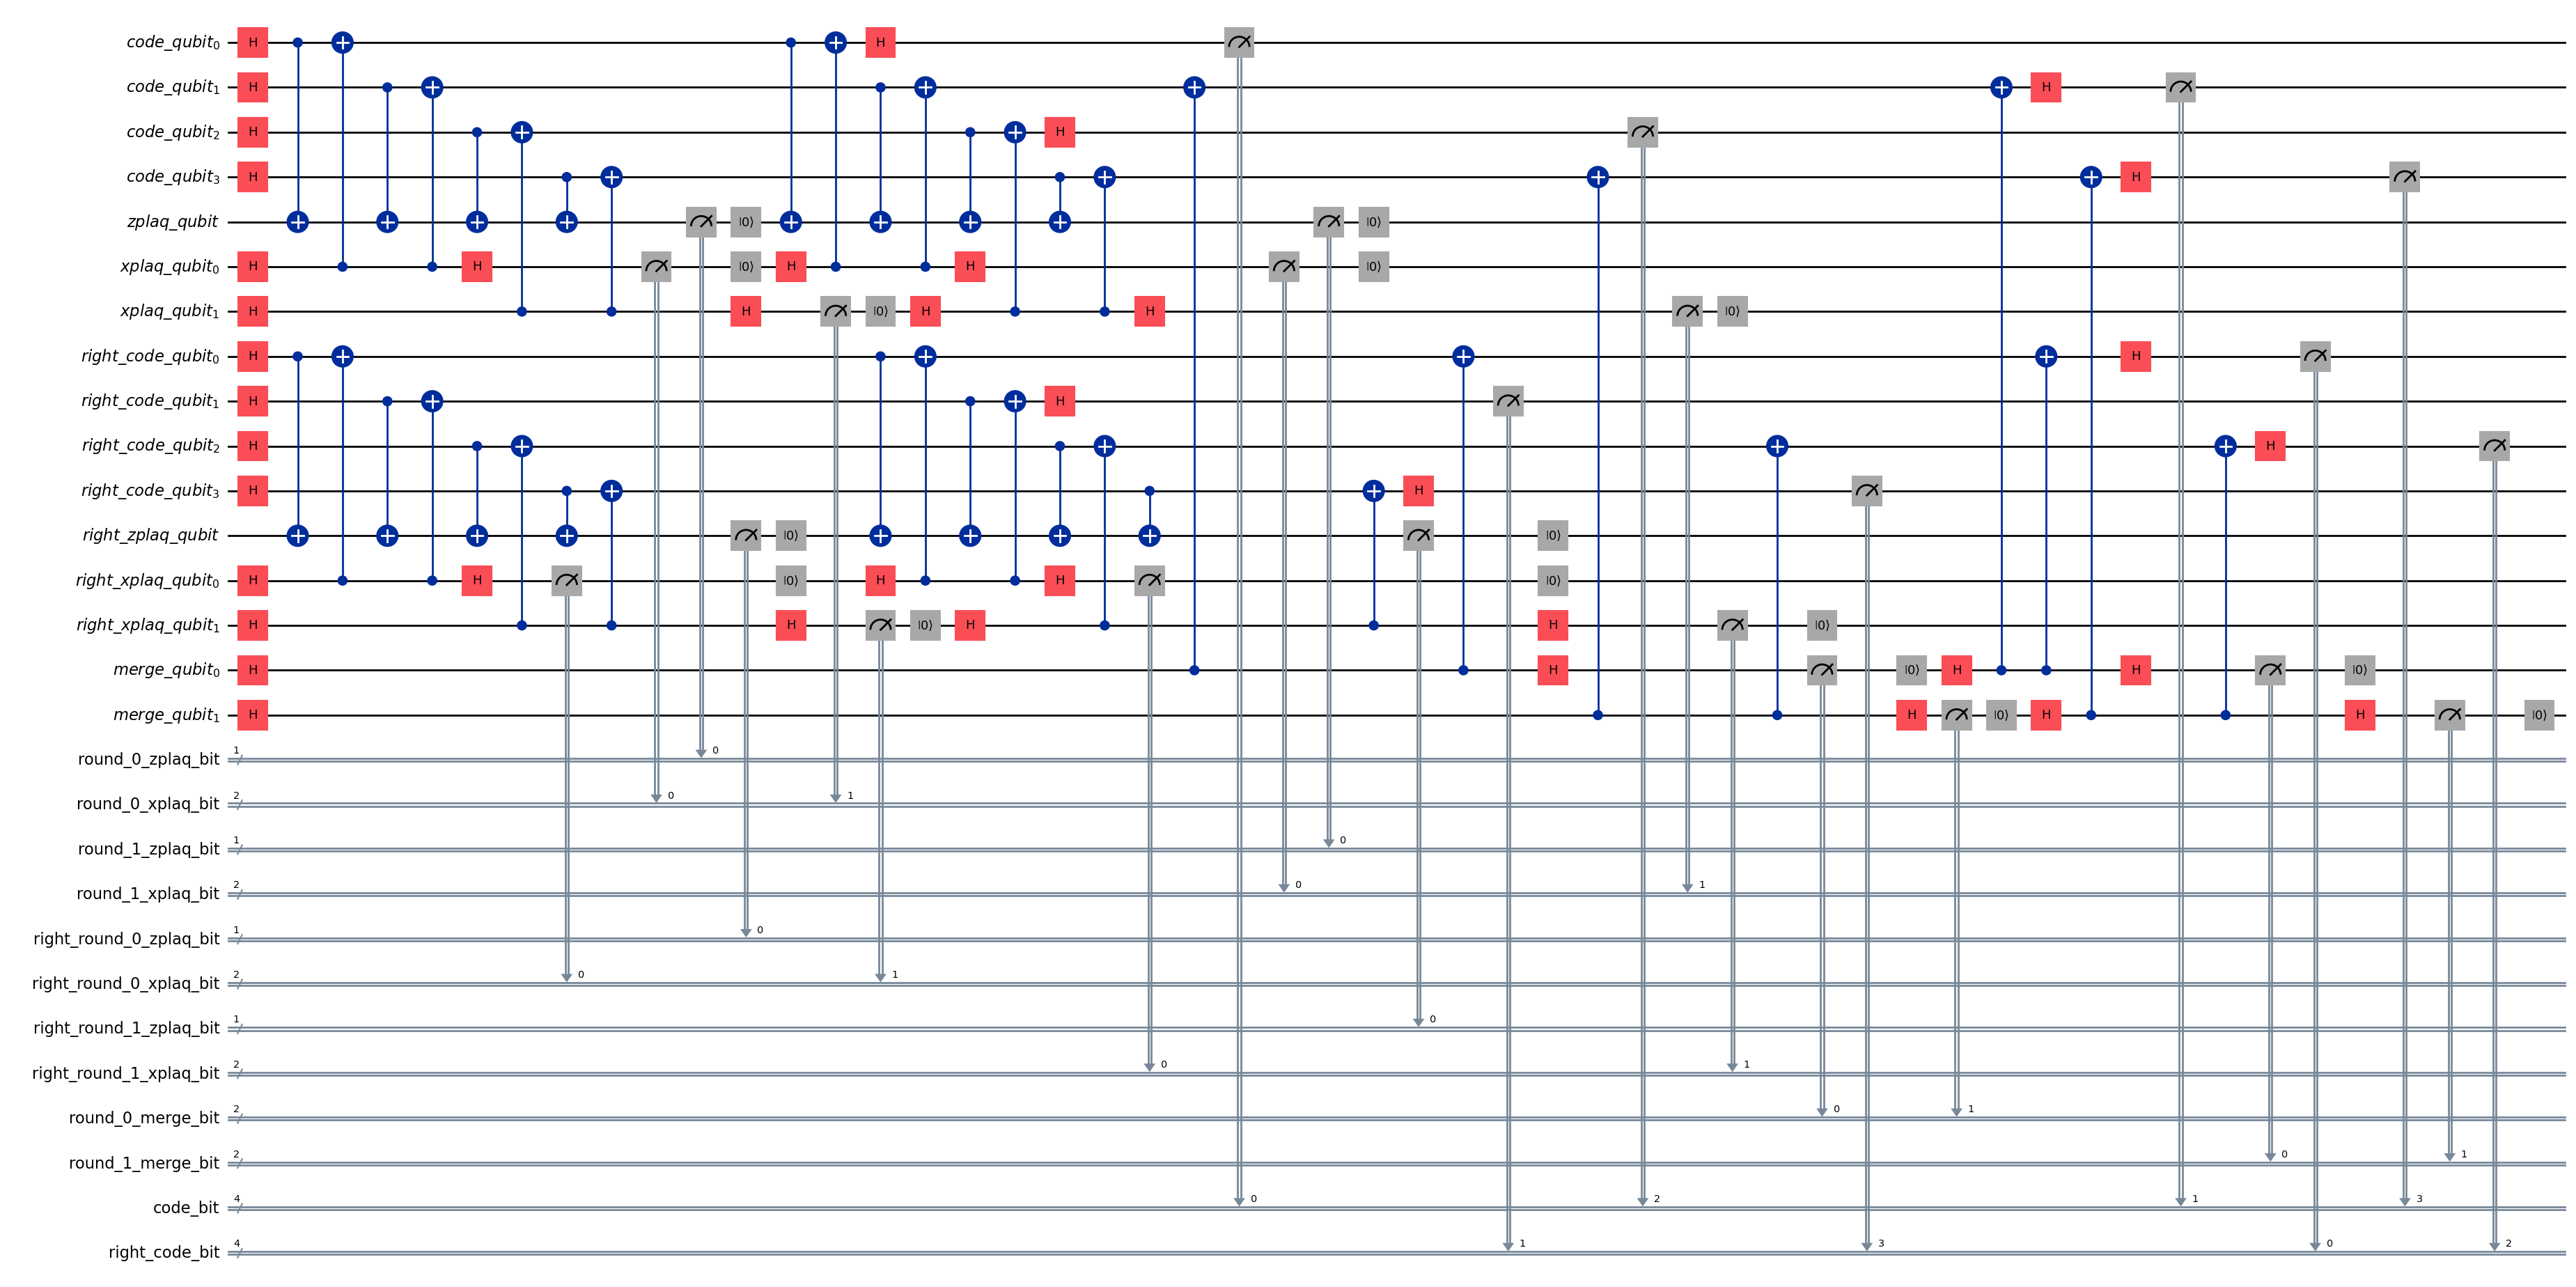

In [17]:
r_merge_circuit_xb_zf = RoughMergeCircuit(d=2, T=3, basis="x")
r_merge_circuit_xb_zf.circuit["0"].draw(output='mpl', fold=-1)

In [18]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
sim = AerSimulator(method="statevector")
result = sim.run(r_merge_circuit_xb_zf.circuit["0"], shots=100).result()

count = result.get_counts()

print(count)


{'1111 1111 00 00 00 1 00 1 00 0 00 0': 10, '0000 1111 11 11 00 1 00 1 00 1 00 1': 6, '0000 1111 11 11 00 0 00 0 00 0 00 0': 8, '0000 0000 00 00 00 1 00 1 00 1 00 1': 8, '0000 0000 00 00 00 1 00 1 00 0 00 0': 3, '1111 0000 11 11 00 1 00 1 00 1 00 1': 4, '0000 0000 00 00 00 0 00 0 00 0 00 0': 2, '1111 1111 00 00 00 0 00 0 00 1 00 1': 3, '1111 0000 11 11 00 0 00 0 00 1 00 1': 7, '1111 0000 11 11 00 1 00 1 00 0 00 0': 10, '0000 0000 00 00 00 0 00 0 00 1 00 1': 8, '1111 1111 00 00 00 0 00 0 00 0 00 0': 7, '0000 1111 11 11 00 0 00 0 00 1 00 1': 6, '1111 1111 00 00 00 1 00 1 00 1 00 1': 6, '1111 0000 11 11 00 0 00 0 00 0 00 0': 7, '0000 1111 11 11 00 1 00 1 00 0 00 0': 5}


In [19]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 0
even parity 100


## Rough Merge in Z Basis. Both Qubits |+>

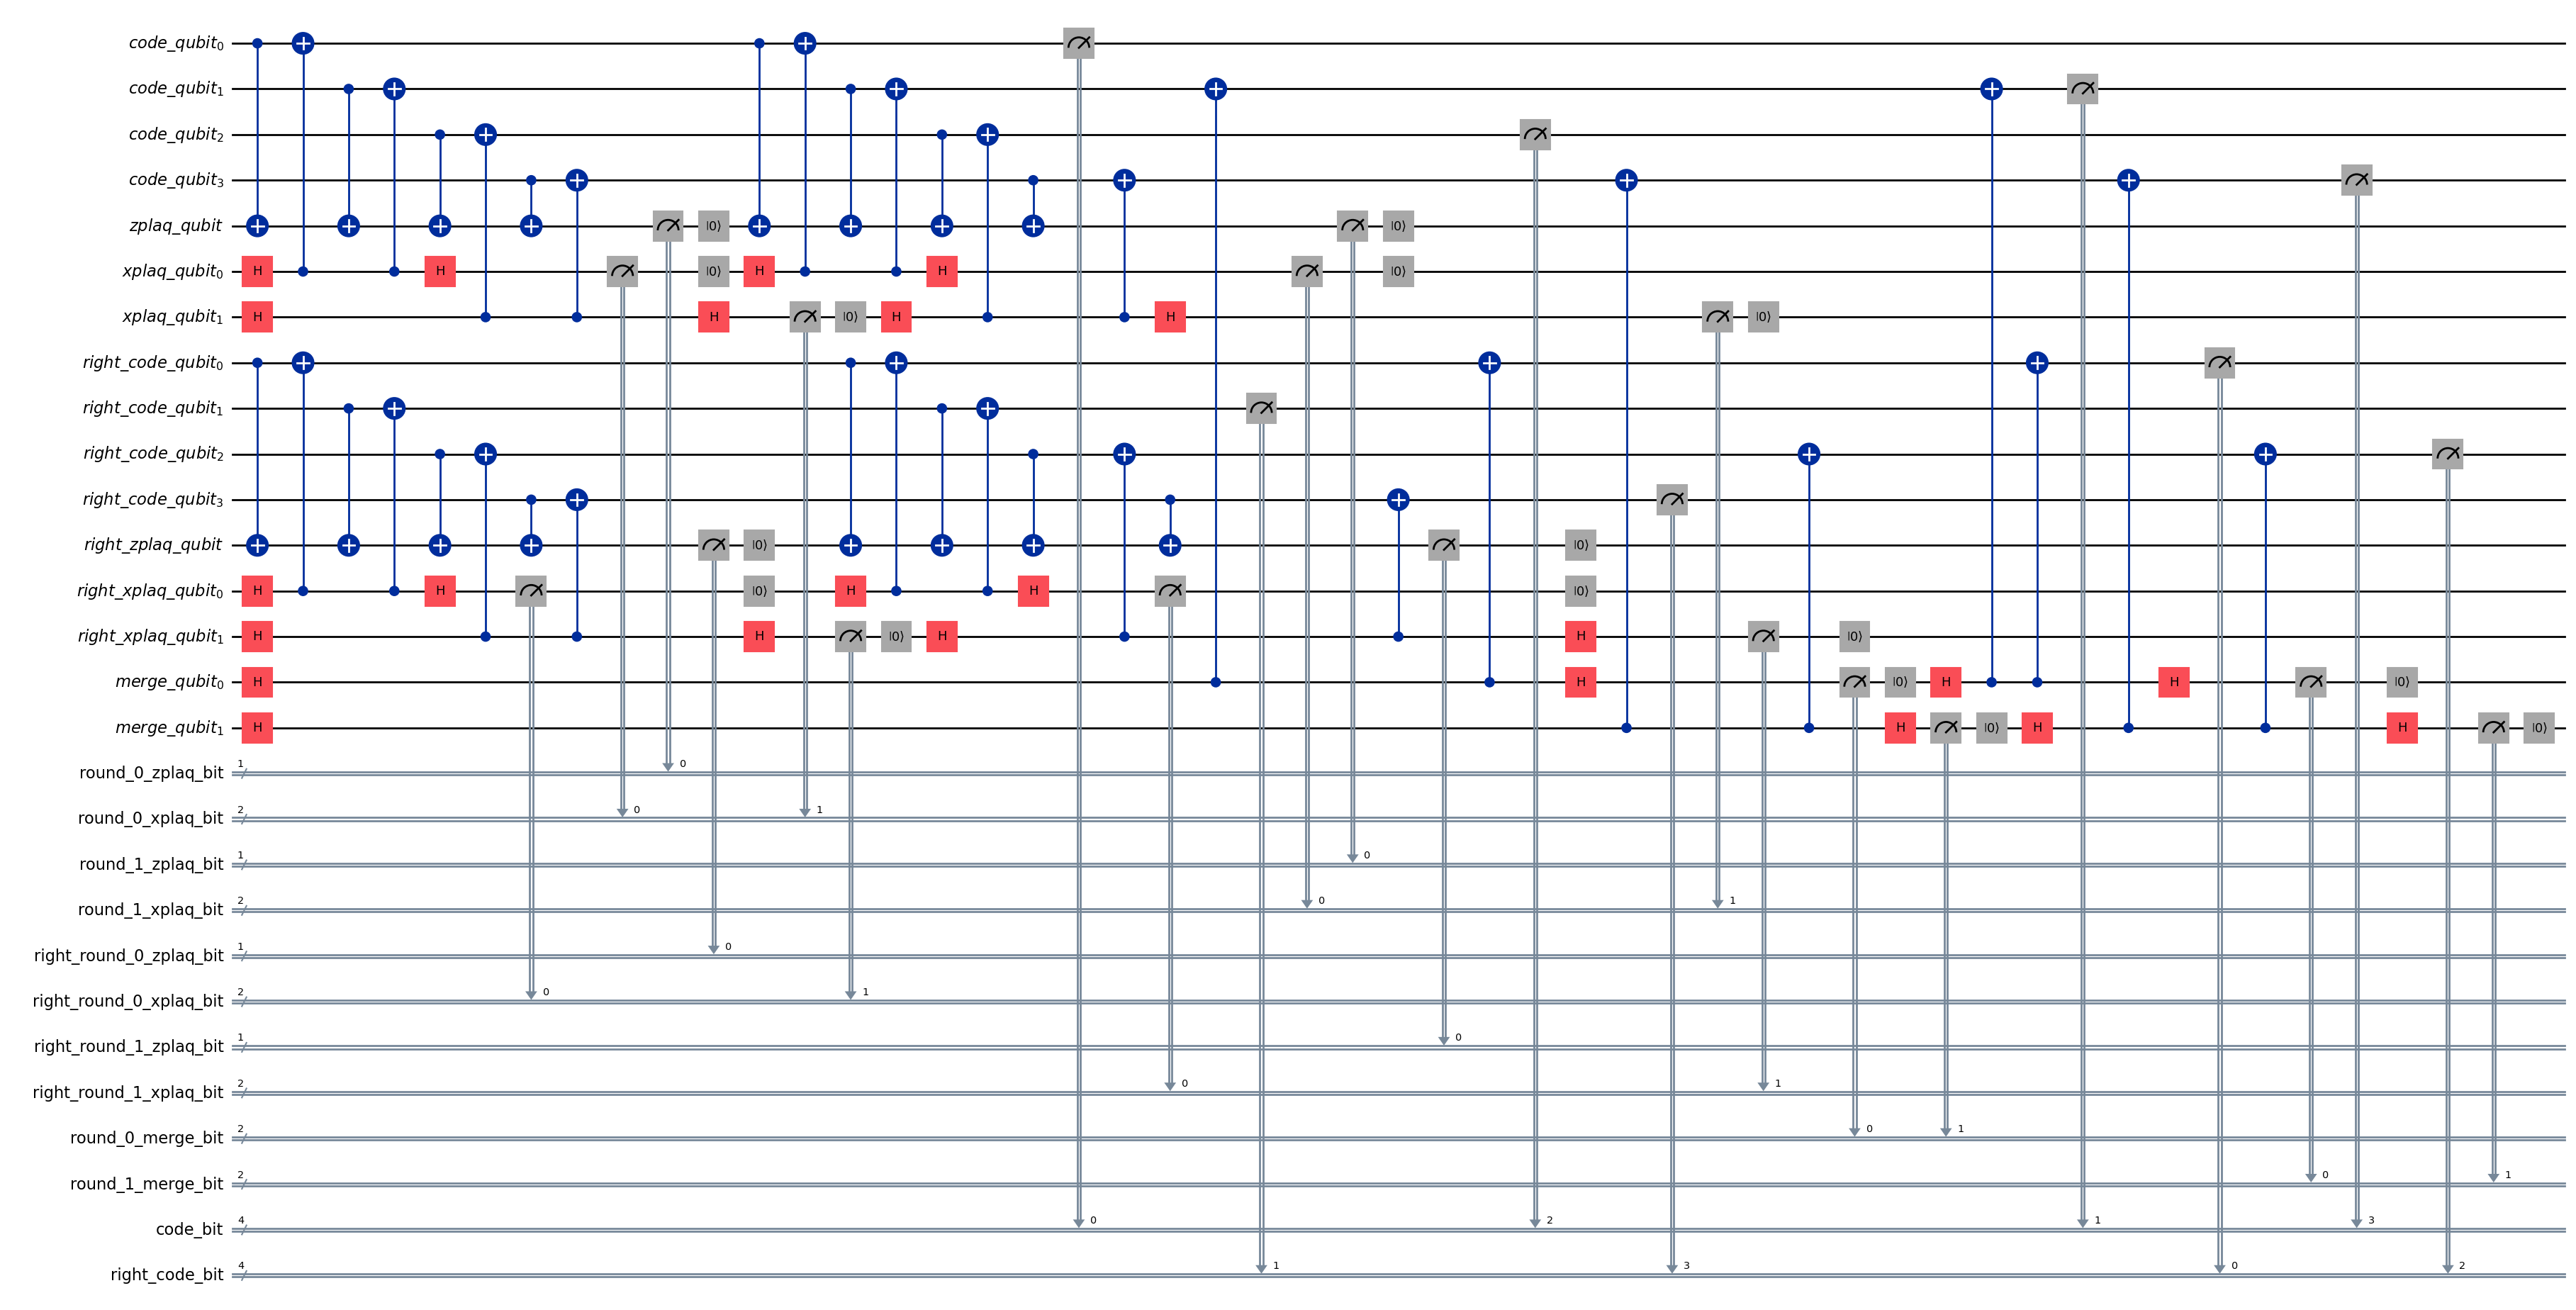

In [20]:
r_merge_circuit_zb = RoughMergeCircuit(d=2, T=3, basis="z")
r_merge_circuit_zb.circuit["0"].draw(output='mpl', fold=-1)

In [21]:
from qiskit_aer.noise import ReadoutError, NoiseModel, depolarizing_error

noise_model = NoiseModel()
sim = AerSimulator(method="statevector")
result = sim.run(r_merge_circuit_zb.circuit["0"], shots=100).result()

count = result.get_counts()

print(count)


{'1010 0101 10 10 01 0 01 0 10 0 10 0': 1, '0111 1011 10 10 00 0 00 0 00 0 00 0': 1, '1101 1110 00 00 00 0 00 0 01 0 01 0': 1, '1111 1111 11 11 10 0 10 0 11 0 11 0': 1, '1101 1101 10 10 00 0 00 0 00 0 00 0': 1, '0101 0101 11 11 11 0 11 0 11 0 11 0': 1, '1100 1100 11 11 01 0 01 0 10 0 10 0': 1, '1011 0111 11 11 01 0 01 0 10 0 10 0': 1, '0100 0111 00 00 11 0 11 0 01 0 01 0': 1, '0011 0000 11 11 11 0 11 0 01 0 01 0': 1, '0100 1000 01 01 01 0 01 0 01 0 01 0': 1, '1010 1001 10 10 11 0 11 0 10 0 10 0': 1, '1011 0111 00 00 11 0 11 0 01 0 01 0': 1, '0010 0001 11 11 10 0 10 0 10 0 10 0': 1, '1001 1001 11 11 00 0 00 0 01 0 01 0': 1, '0111 0100 10 10 00 0 00 0 11 0 11 0': 1, '1101 0001 01 01 01 0 01 0 01 0 01 0': 1, '1001 1001 01 01 01 0 01 0 11 0 11 0': 1, '0100 1011 10 10 10 0 10 0 10 0 10 0': 1, '1100 1100 00 00 11 0 11 0 00 0 00 0': 1, '1110 1101 00 00 10 0 10 0 11 0 11 0': 1, '0010 0001 10 10 10 0 10 0 01 0 01 0': 1, '1011 1000 10 10 10 0 10 0 00 0 00 0': 1, '0001 1110 10 10 01 0 01 0 10 0 1

In [22]:
odd_parity = 0
even_parity = 0
for key, val in count.items():
    measurements = key.split(" ")

    if measurements[2] == "00" or measurements[2] == "11":
        even_parity += 1*val
    else:
        odd_parity += 1*val

print("odd parity", odd_parity)
print("even parity", even_parity)


odd parity 42
even parity 58
